In [1]:
import requests
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

from Data import data_rates, std, Pearson_cor, data_closing_prices, rates_for_backtest, closing_for_backtest, rates_for_bootstrap, closing_for_bootstrap

In this project, we will compare the performance and the risk of lumpsum investing a loan and investing the cash flows of the loan on an 7 years period (3 years only interest and 4 years of repayement).

We will use the Sharpe Ratio as a measure of risk-adjusted return to determine the optimal
allocation between the S&P 500, the TSX, and an ex-US/Canada index (MSCI EAFE).
The data used for thisanalysis includes historical returns and closing prices for these indices, as well as the policy rate.
The goal is to find the allocation that maximizes the Sharpe Ratio, indicating the best risk-adjusted
return for the given investment strategy.

We will also analyse the risk and return by backtesting, and by making monte carlo simulations
(boostrap,normal distribution and student distribution) to compare the performance of the two
strategies under different market conditions.

For the calculation of the Sharpe ratio we will use as the risk free rate, the cost of a loan at the rate of T+0.25.

In [2]:
from Fonctions import Mod_Sharpe_Ratio, find_optimal_allocation


print(find_optimal_allocation())

Optimal Allocation: SP500: 100%, TSX: 0%, Ex_US_Can: 0% 
 With a Sharpe Ratio of 0.9559


Since the data start in 2009, it has a bias that favorize the SP500.
My assumption war that the optimal allocation will be of 70% SP500, 20% SPTSX and 10% MSCI EAFE.
To remedy this bias, I will use an allocation of 85% SP500, 10% SPTSX and 5% MSCI EAFE

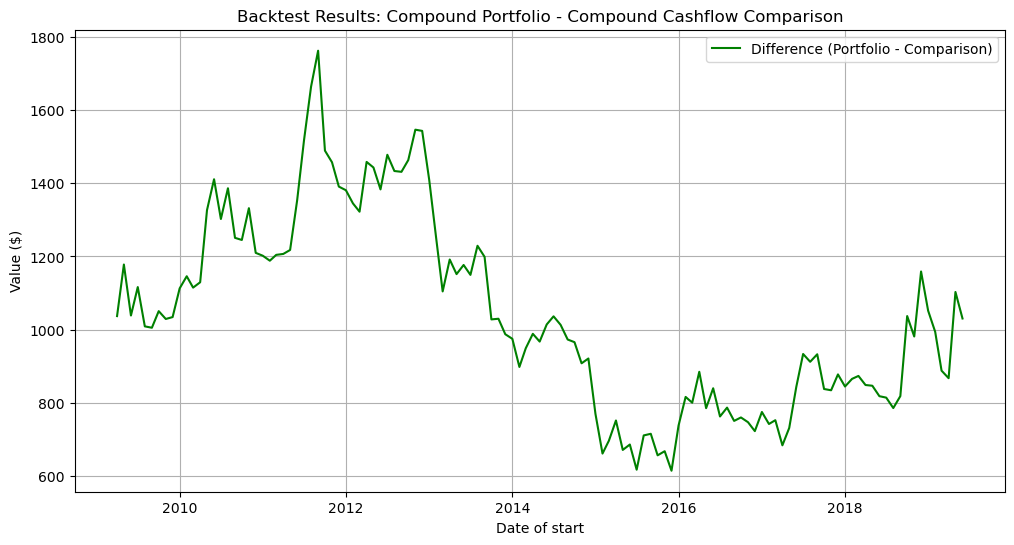

None
Results Analysis for Backtest:
Number of Simulations: 123
Average Difference: 1040.09
Percentage of Positive Outcomes: 100.00%
Maximum Difference: 1762.52
Minimum Difference: 613.93
5% Quantile: 683.62
95% Quantile: 1476.53


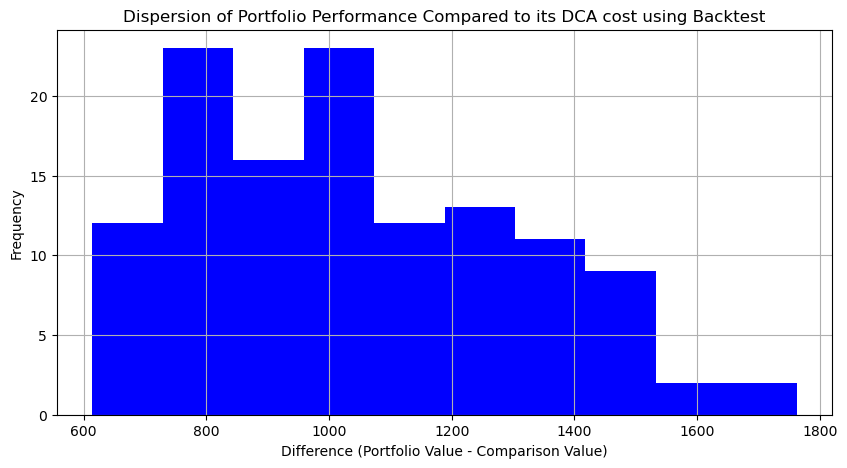

None


In [3]:
from Fonctions import backtest_portfolio, plot_backtest_results, dispertion_of_results

print(plot_backtest_results(backtest_portfolio(85, 10, 7)))
print(dispertion_of_results(backtest_portfolio(85, 10, 7), 10, "Backtest"))

Since the correlation between Policy Rate and SP500 returns: 0.0185, I will not tie the Policy Rate and the return of
the portfolio, instead, I will test the project in different scenario.

It allows us to use data, for the bootsrap, starting in 2003 instead of 2009.

Results Analysis for Monte Carlo with Bootstrap and 5% loan rate:
Number of Simulations: 1500
Average Difference: 487.24
Percentage of Positive Outcomes: 85.33%
Maximum Difference: 3512.26
Minimum Difference: -547.99
5% Quantile: -184.74
95% Quantile: 1405.70


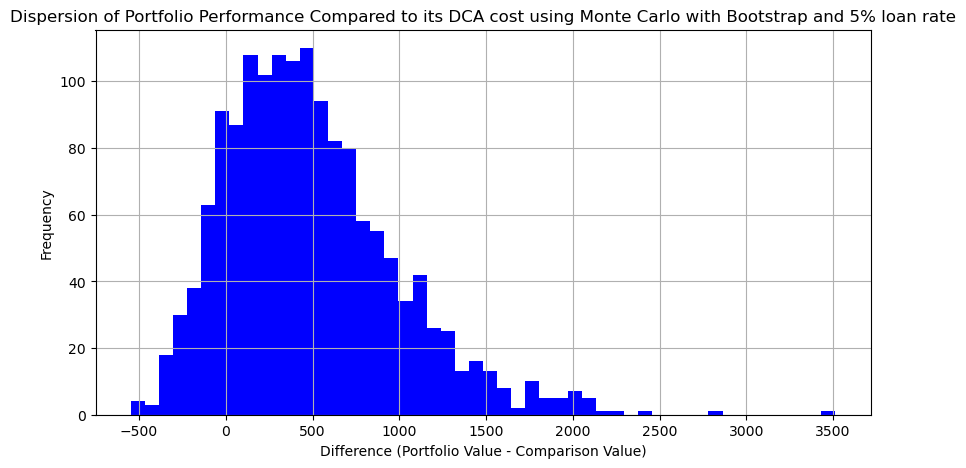

None
Results Analysis for Monte Carlo with Normal Distribution and 5% loan rate:
Number of Simulations: 1500
Average Difference: 515.14
Percentage of Positive Outcomes: 88.33%
Maximum Difference: 2994.50
Minimum Difference: -541.92
5% Quantile: -130.48
95% Quantile: 1394.62


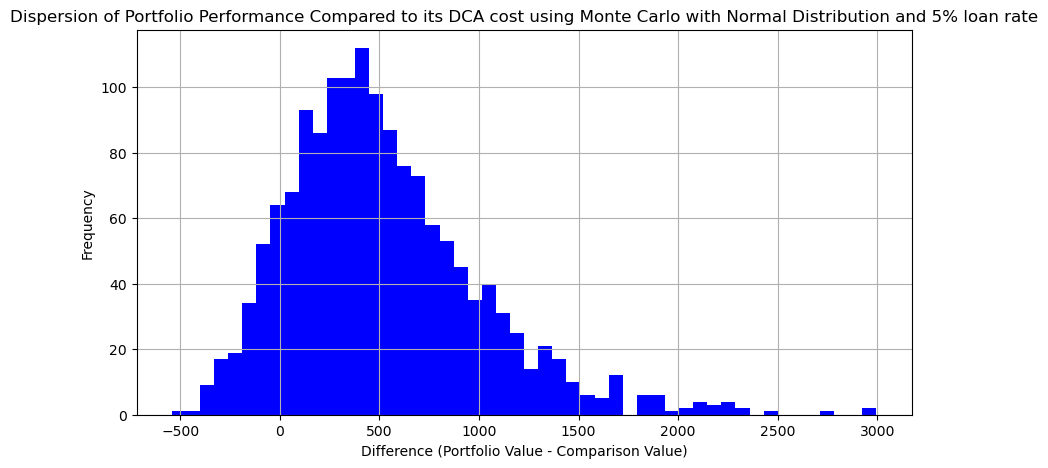

None
Results Analysis for Monte Carlo with Student's t-Distribution and 5% loan rate:
Number of Simulations: 1500
Average Difference: 476.07
Percentage of Positive Outcomes: 85.33%
Maximum Difference: 2865.71
Minimum Difference: -1444.08
5% Quantile: -182.49
95% Quantile: 1388.21


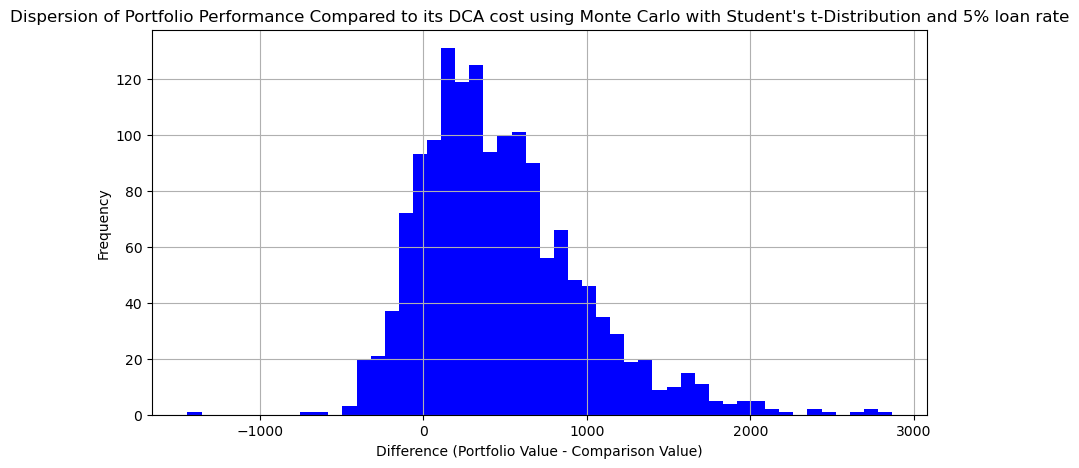

None


In [4]:
from Fonctions import montecarlo, normal, bootstrap, student

print(
    dispertion_of_results(
        montecarlo(85, 10, 7, 1500, 0.05, bootstrap),
        50,
        "Monte Carlo with Bootstrap and 5% loan rate"
    )
)
print(
    dispertion_of_results(
        montecarlo(85, 10, 7, 1500, 0.05, normal),
        50,
        "Monte Carlo with Normal Distribution and 5% loan rate"
    )
)
print(
    dispertion_of_results(
        montecarlo(85, 10, 7, 1500, 0.05, student),
        50,
        "Monte Carlo with Student's t-Distribution and 5% loan rate"
    )
)

Results Analysis for Monte Carlo with Bootstrap and 8% loan rate:
Number of Simulations: 1500
Average Difference: 232.34
Percentage of Positive Outcomes: 66.60%
Maximum Difference: 2484.86
Minimum Difference: -745.39
5% Quantile: -370.97
95% Quantile: 1056.94


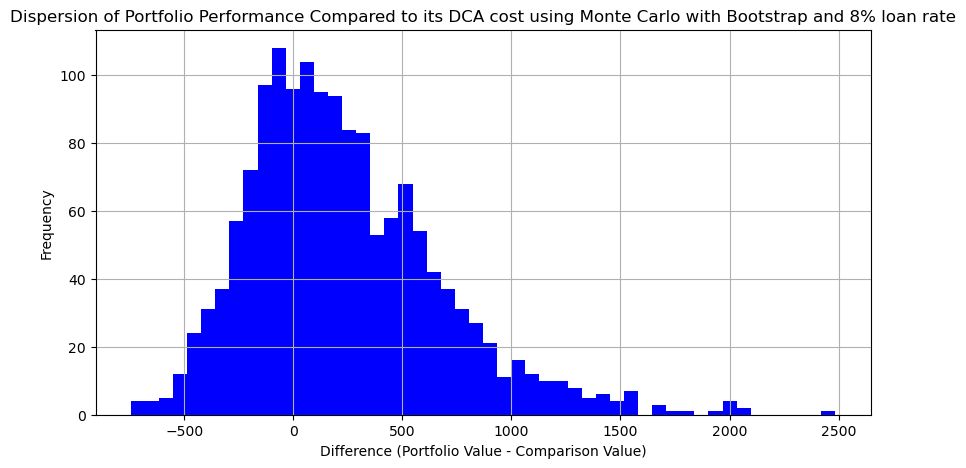

None
Results Analysis for Monte Carlo with Normal Distribution and 8% loan rate:
Number of Simulations: 1500
Average Difference: 236.95
Percentage of Positive Outcomes: 66.20%
Maximum Difference: 2591.03
Minimum Difference: -706.26
5% Quantile: -355.19
95% Quantile: 1068.29


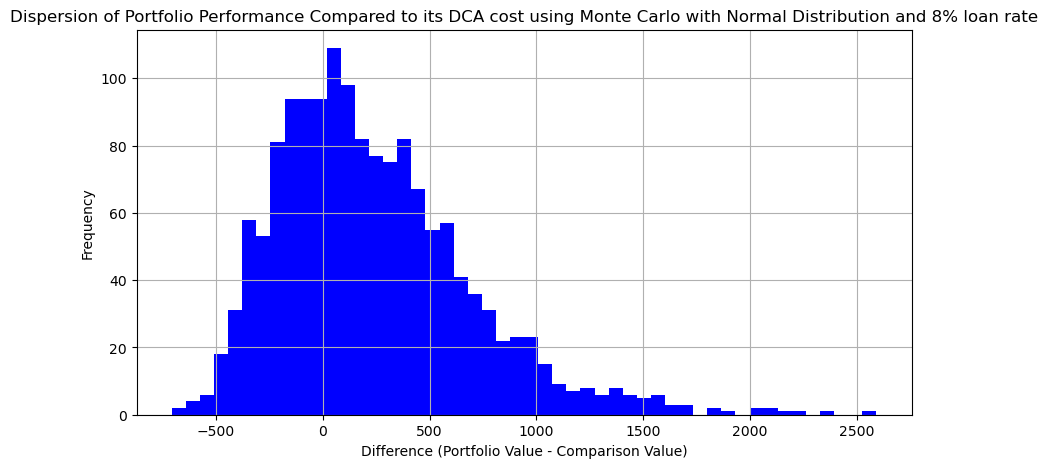

None
Results Analysis for Monte Carlo with Student's t-Distribution and 8% loan rate:
Number of Simulations: 1500
Average Difference: 247.28
Percentage of Positive Outcomes: 67.33%
Maximum Difference: 3091.57
Minimum Difference: -905.34
5% Quantile: -333.01
95% Quantile: 1059.86


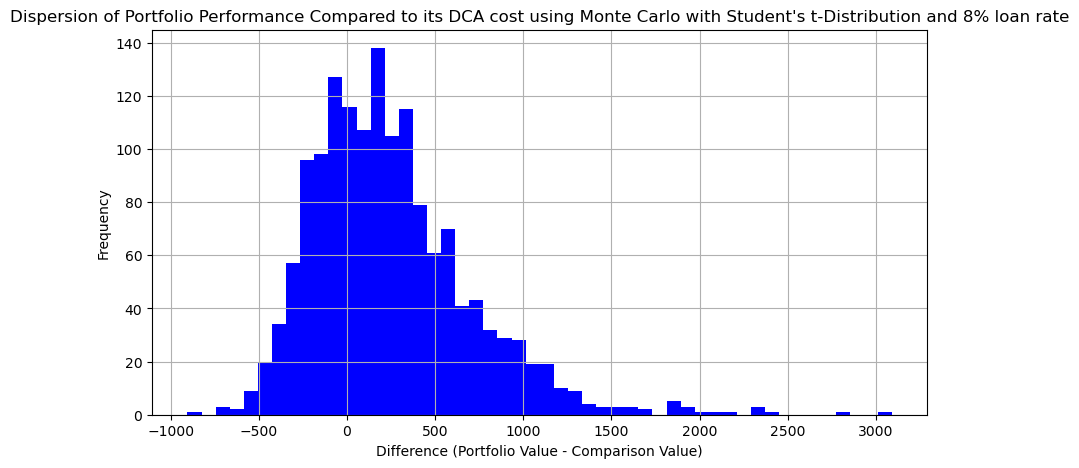

None


In [5]:
print(dispertion_of_results(montecarlo(85, 10, 7, 1500, 0.08, bootstrap), 50, "Monte Carlo with Bootstrap and 8% loan rate"))
print(dispertion_of_results(montecarlo(85, 10, 7, 1500, 0.08, normal), 50, "Monte Carlo with Normal Distribution and 8% loan rate"))
print(dispertion_of_results(montecarlo(85, 10, 7, 1500, 0.08, student), 50, "Monte Carlo with Student's t-Distribution and 8% loan rate"))

For the amount of the loan, we will lock at the cashflow dependent of the lenght of the repayement period and the loan rate.

In [6]:
from Fonctions import cashflow

print(cashflow(1000, 0.05, 5))
print(cashflow(1000, 0.08, 5))

For a loan of 1000 with a rate of 5.0% and a repayement period of 2 years: 
 
First 3 years of interest only cashflow: 
Mounthly cashflow: 4.0741237836483535
Yearly cashflow: 48.88948540378024

Repayement period cashflow: 
Mounthly cashflow: 43.821672892412224
Yearly cashflow: 525.8600747089467



For a loan of 1000 with a rate of 8.0% and a repayement period of 2 years: 
 
First 3 years of interest only cashflow: 
Mounthly cashflow: 6.43403011000343
Yearly cashflow: 77.20836132004116

Repayement period cashflow: 
Mounthly cashflow: 45.100076444158816
Yearly cashflow: 541.2009173299058





In [7]:
print(cashflow(1000, 0.05, 7))
print(cashflow(1000, 0.08, 7))

For a loan of 1000 with a rate of 5.0% and a repayement period of 4 years: 
 
First 3 years of interest only cashflow: 
Mounthly cashflow: 4.0741237836483535
Yearly cashflow: 48.88948540378024

Repayement period cashflow: 
Mounthly cashflow: 22.979022289600255
Yearly cashflow: 275.7482674752031



For a loan of 1000 with a rate of 8.0% and a repayement period of 4 years: 
 
First 3 years of interest only cashflow: 
Mounthly cashflow: 6.43403011000343
Yearly cashflow: 77.20836132004116

Repayement period cashflow: 
Mounthly cashflow: 24.282094333671914
Yearly cashflow: 291.38513200406294





There is always a possibility that life gets in the way and that you can't afford the repayement cashflow. Therefore, is it interesting to look at the repartition and the risk if you only invest for the 3 year interest only period and after repay the loan with the money from the investement instead of the revenues from a futur job.

Results Analysis for Bootstrap with 5% loan rate and a 3 year exit:
Number of Simulations: 1500
Average Difference: 211.92
Percentage of Positive Outcomes: 78.60%
Maximum Difference: 1277.76
Minimum Difference: -431.96
5% Quantile: -165.05
95% Quantile: 654.81


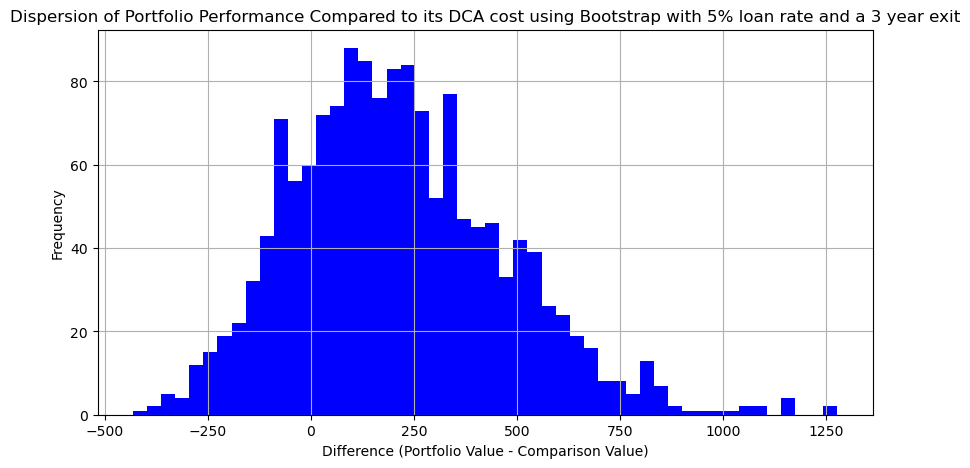

None
Results Analysis for Bootstrap with 8% loan rate and a 3 year exit:
Number of Simulations: 1500
Average Difference: 93.97
Percentage of Positive Outcomes: 61.80%
Maximum Difference: 1043.50
Minimum Difference: -439.48
5% Quantile: -247.33
95% Quantile: 504.64


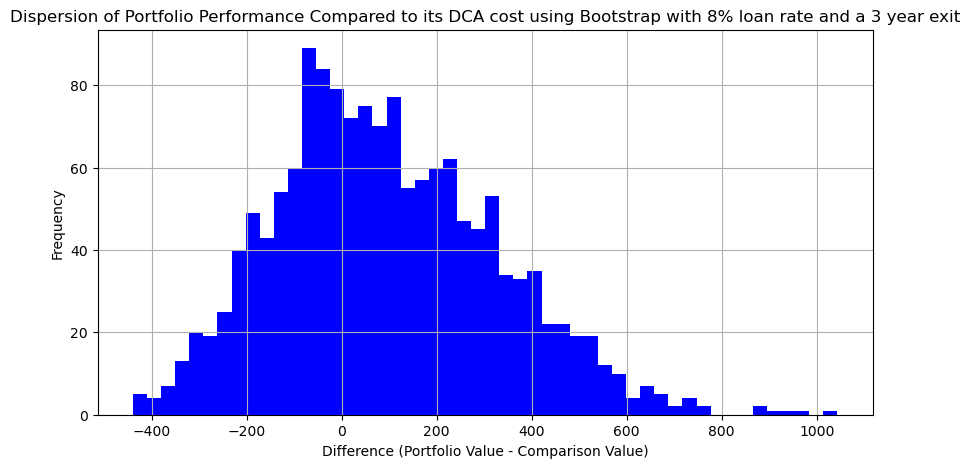

None


In [8]:
from Fonctions import exit_3_years

print(dispertion_of_results(exit_3_years(85, 10, 1500, 0.05, bootstrap), 50, "Bootstrap with 5% loan rate and a 3 year exit"))
print(dispertion_of_results(exit_3_years(85, 10, 1500, 0.08, bootstrap), 50, "Bootstrap with 8% loan rate and a 3 year exit"))